# IPL Data Analysis
## Exploratory Data Analysis Using Pandas
### DataSet:IPL Matches from 2008-2024

In [1]:
#____importing the library____
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the IPL dataset
ball=pd.read_csv('Data/Ballbyball_detail_2008_to_2024.csv')
matches=pd.read_csv('Data/matches (1).csv')

### Understanding the shape of dataset

In [3]:
matches.shape

(1095, 20)

In [4]:
ball.shape

(260920, 17)

### Checking if there any null value in dataset

In [5]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [6]:
ball.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

### Handling the missing value of matches dataset of column method and rest of missing value is intitutional 

In [7]:
matches['method']=matches['method'].fillna('Normal')

### Renaming the old ipl team name with new name of ipl team so that it will not create problem during anlaysis

In [8]:
team_mapping = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
matches['team1']=matches['team1'].replace(team_mapping.keys(),team_mapping.values())
matches['team2']=matches['team2'].replace(team_mapping.keys(),team_mapping.values())
matches['winner']=matches['winner'].replace(team_mapping.keys(),team_mapping.values())
matches['toss_winner']=matches['toss_winner'].replace(team_mapping.keys(),team_mapping.values())
    

### Matches Dataset Analsysis
#### Basic Exploritation

#### How many total matches were played across all season

In [9]:
result=matches.shape[0]
print(f'The total matches play in all season:{result}')

The total matches play in all season:1095


#### How many unique team have play in all season?

In [10]:
total_team=pd.concat((matches['team1'],matches['team2']))
result=total_team.nunique()
print(f"Total unique team play in all season:{result}")

Total unique team play in all season:15


#### Which season are covered in this dataset?

In [11]:
result=matches['season'].unique()
result

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

#### How many matches are played in each season?

The total matches played in each season:season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64


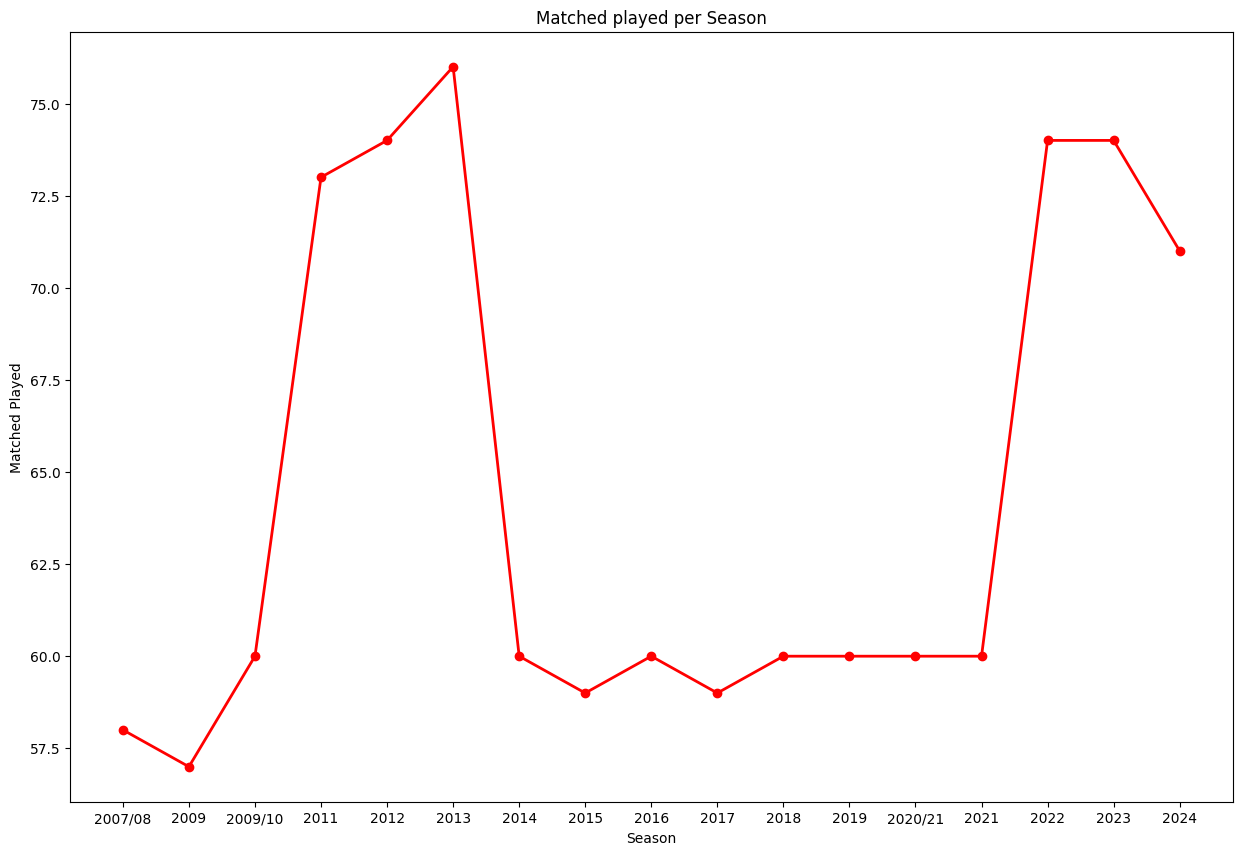

In [12]:
result=matches.groupby('season')['id'].count()
print(f'The total matches played in each season:{result}')

#Visualization of  matches played in each season
plt.figure(figsize=(15,10))
x=result.index
y=result.values
plt.plot(x,y,color='red',linewidth=2,marker='o')
plt.title('Matched played per Season')
plt.xlabel('Season')
plt.ylabel('Matched Played')
plt.show()

#### The IPL first season 2007/08 started with 58 matches and kept the count steady around 57-60 matches in many seasons.But in some season around 74-76 matches were played 

### Team Analysis

#### Which team have won the most matches overall?

The most win team in ipl matches is:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Name: count, dtype: int64


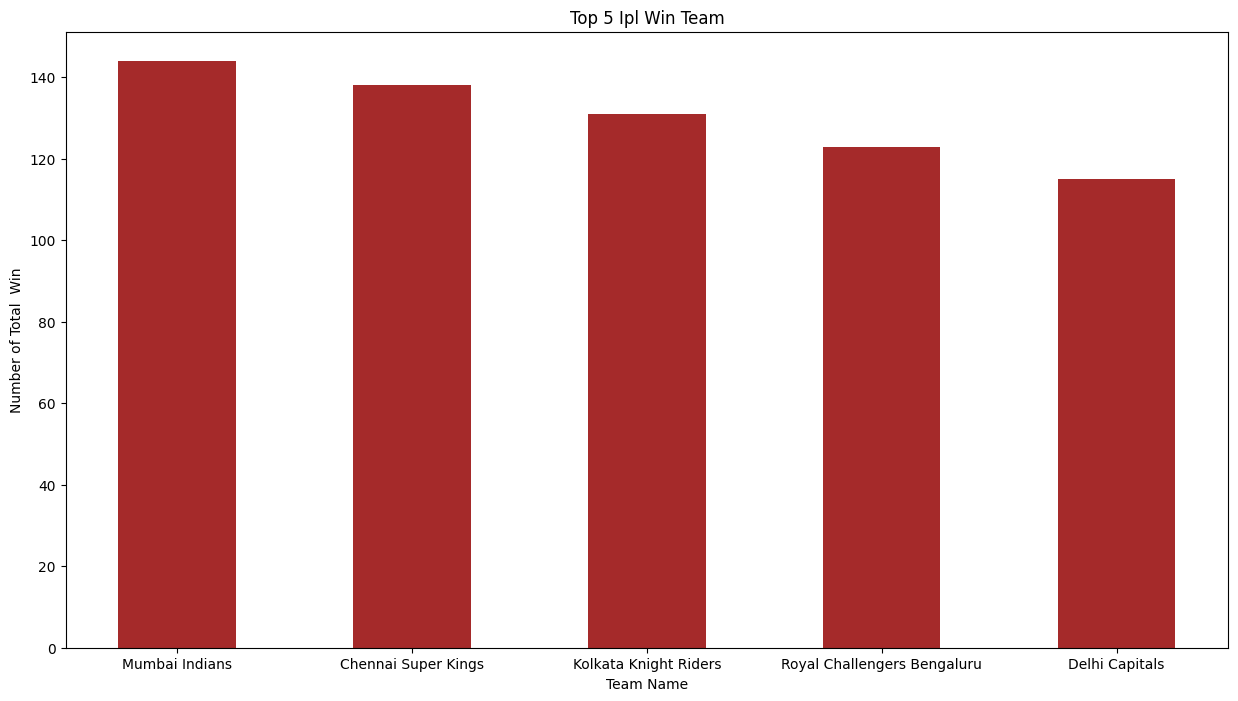

In [13]:
total_matches=matches[matches['winner'].notnull()]
most_win_team=total_matches['winner'].value_counts().head(5)
print(f'The most win team in ipl matches is:\n{most_win_team}')

#Visualziation of which team won the most matches
plt.figure(figsize=(15,8))
x=most_win_team.index
y=most_win_team.values
plt.bar(x,y,color='brown',width=0.5)
plt.title("Top 5 Ipl Win Team")
plt.xlabel("Team Name")
plt.ylabel("Number of Total  Win")
plt.show()

#### Mumbai Indians have won the most matches overall with 144 victories, which was surprising to me, followed closely by Chennai Super Kings with 138 wins.

#### Which team has lost the most matches?

Most lost team in ipl:
Delhi Capitals                 135
Punjab Kings                   134
Royal Challengers Bengaluru    129
Kolkata Knight Riders          120
Mumbai Indians                 117
Name: count, dtype: int64


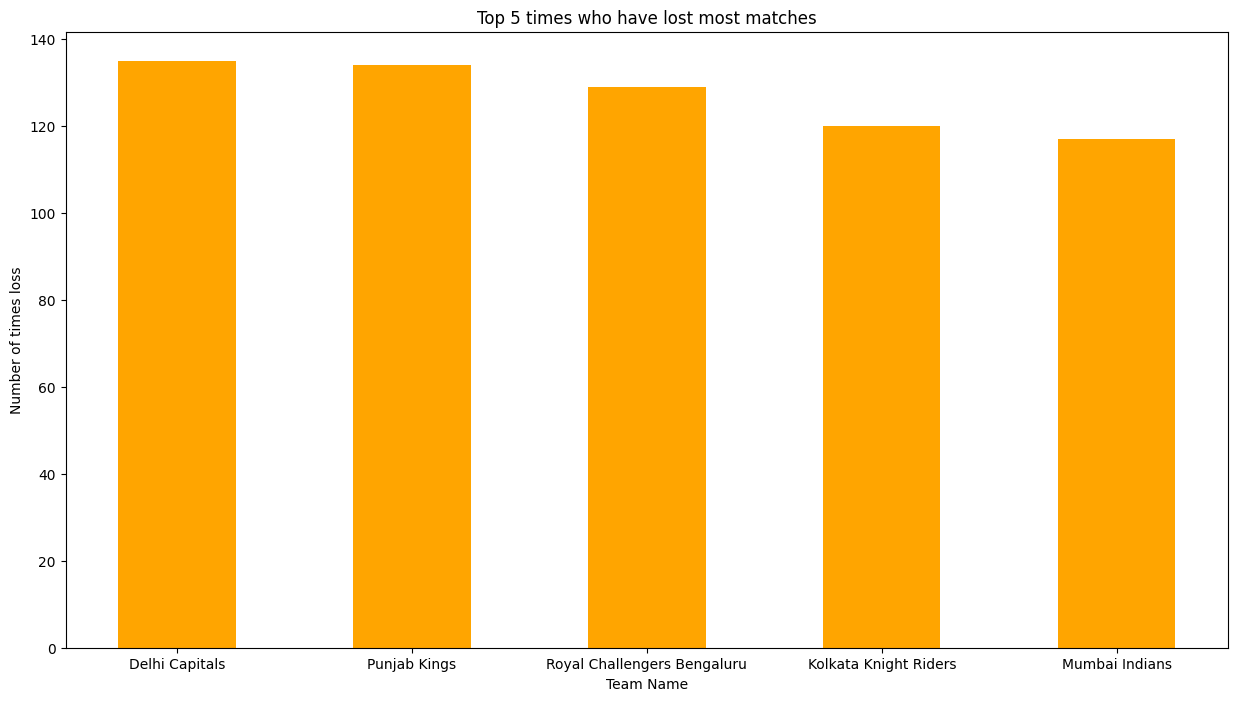

In [15]:
total_matches=matches[matches['winner'].notnull()]
total_teams=pd.concat((total_matches['team1'],total_matches['team2']))
total_played=total_teams.value_counts()
total_wins=total_matches['winner'].value_counts()
most_lost_team=total_played.subtract(total_wins,fill_value=0).sort_values(ascending=False).head(5)
print(f'Most lost team in ipl:\n{most_lost_team}')

#Visulization of which top 5 team had lost most matches
x=most_lost_team.index
y=most_lost_team.values
plt.figure(figsize=(15,8))
plt.bar(x,y,width=0.5,color='orange')
plt.title("Top 5 times who have lost most matches")
plt.xlabel("Team Name")
plt.ylabel("Number of times loss")
plt.show()

#### Delhi Capitals have lost the most matches overall with 135 defeats, followed closely by Punjab Kings with 134. That shows these teams have struggled to convert games into wins compared to the top performers.

#### Which team has won the most toss?

The top 5 winning team in toss is:
toss_winner
Mumbai Indians                 143
Delhi Capitals                 130
Kolkata Knight Riders          122
Chennai Super Kings            122
Royal Challengers Bengaluru    121
Name: count, dtype: int64


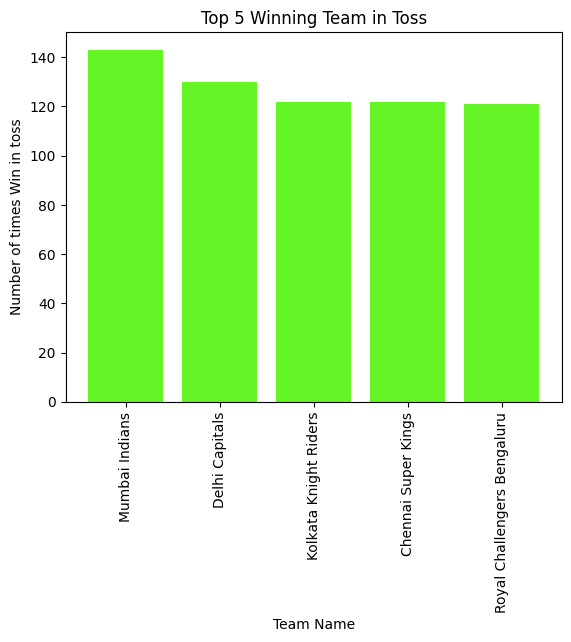

In [16]:
result=matches['toss_winner'].value_counts().head(5)
print(f'The top 5 winning team in toss is:\n{result}')

#Visualization of top 5 winning team in toss
x=result.index
y=result.values
plt.bar(x,y,color='#65F527')
plt.title("Top 5 Winning Team in Toss")
plt.xlabel("Team Name")
plt.ylabel("Number of times Win in toss")
plt.xticks(rotation='vertical')
plt.show()


#### Mumbai Indians have won the toss the most times (143) and also lead in total match victories. Interestingly, the second‑most successful team in terms of wins in toss is Delhi Capitals, which is a little surprising given their limited win success compared to Chennai Super Kings

#### Does winning toss help team to won the match?

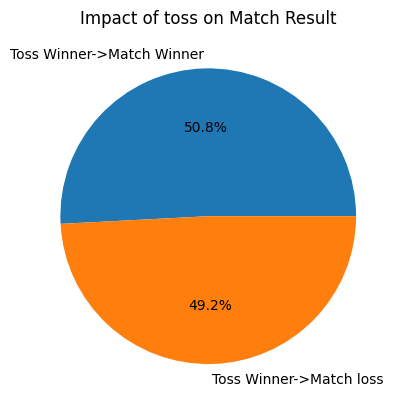

In [17]:
total_matches=matches[matches['winner'].notnull()]
total=total_matches.shape[0]
winner=total_matches[total_matches['winner']==total_matches['toss_winner']].shape[0]
win_percent=(winner/total)*100
win_percent

#Visulization
total_win_match=winner
total_loss_match=total-winner
plt.pie([total_win_match,total_loss_match],labels=['Toss Winner->Match Winner','Toss Winner->Match loss'],autopct="%1.1f%%")
plt.title("Impact of toss on Match Result")
plt.show()


#### From the visualization, we can see that teams winning the toss have a slightly higher chance of winning the match. This indicates that while the toss provides a small advantage but match outcomes are still largely determined by overall performance.

#### Which team choose bat vs filed after winning the toss?

                    toss_winner toss_decision  total
0           Chennai Super Kings         field     63
1           Chennai Super Kings           bat     59
2               Deccan Chargers           bat     24
3               Deccan Chargers         field     19
4                Delhi Capitals         field     89
5                Delhi Capitals           bat     41
6                 Gujarat Lions         field     14
7                 Gujarat Lions           bat      1
8                Gujarat Titans         field     16
9                Gujarat Titans           bat      6
10         Kochi Tuskers Kerala         field      5
11         Kochi Tuskers Kerala           bat      3
12        Kolkata Knight Riders         field     84
13        Kolkata Knight Riders           bat     38
14         Lucknow Super Giants         field     13
15         Lucknow Super Giants           bat      6
16               Mumbai Indians         field     90
17               Mumbai Indians           bat 

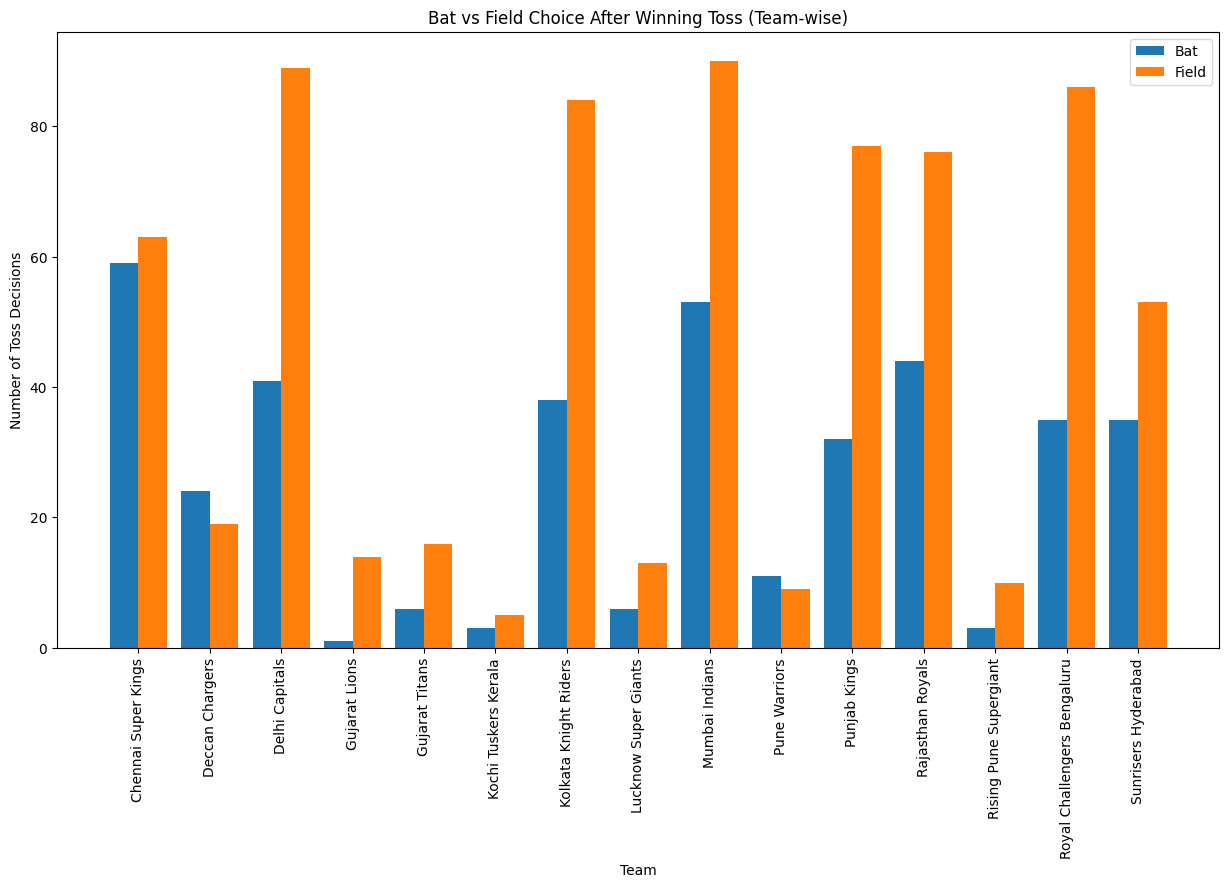

In [19]:
result=(matches.groupby(['toss_winner'],as_index=False)['toss_decision']
        .value_counts().rename(columns={'count':'total'}))
print(result)

#visualization
pivot_result=result.pivot_table(index='toss_winner',columns='toss_decision',values='total')
teams=pivot_result.index
bat_count=pivot_result['bat']
field_count=pivot_result['field']
plt.figure(figsize=(15,8))
plt.bar(np.arange(len(teams))-0.2,bat_count,width=0.4,label='Bat')
plt.bar(np.arange(len(teams))+0.2,field_count,width=0.4,label='Field')
plt.title("Bat vs Field Choice After Winning Toss (Team-wise)")
plt.xlabel("Team")
plt.ylabel("Number of Toss Decisions")
plt.xticks(np.arange(len(teams)),teams,rotation='vertical')
plt.legend()
plt.show()

#### Which team have the highest win % at home city?
* team1 is home team
* team2 is away team
  

Highest home win at city is:
                      Team_Name  Win_Percent
13         Lucknow Super Giants        72.73
7           Chennai Super Kings        58.59
3                Mumbai Indians        56.91
5              Rajasthan Royals        54.46
4         Kolkata Knight Riders        53.72
14               Gujarat Titans        52.38
10          Sunrisers Hyderabad        51.16
12       Rising Pune Supergiant        50.00
0   Royal Challengers Bengaluru        49.65
2                Delhi Capitals        48.80
1                  Punjab Kings        43.90
8          Kochi Tuskers Kerala        42.86
6               Deccan Chargers        33.33
11                Gujarat Lions        31.25
9                 Pune Warriors        26.09


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Lucknow Super Giants'),
  Text(1, 0, 'Chennai Super Kings'),
  Text(2, 0, 'Mumbai Indians'),
  Text(3, 0, 'Rajasthan Royals'),
  Text(4, 0, 'Kolkata Knight Riders'),
  Text(5, 0, 'Gujarat Titans'),
  Text(6, 0, 'Sunrisers Hyderabad'),
  Text(7, 0, 'Rising Pune Supergiant'),
  Text(8, 0, 'Royal Challengers Bengaluru'),
  Text(9, 0, 'Delhi Capitals'),
  Text(10, 0, 'Punjab Kings'),
  Text(11, 0, 'Kochi Tuskers Kerala'),
  Text(12, 0, 'Deccan Chargers'),
  Text(13, 0, 'Gujarat Lions'),
  Text(14, 0, 'Pune Warriors')])

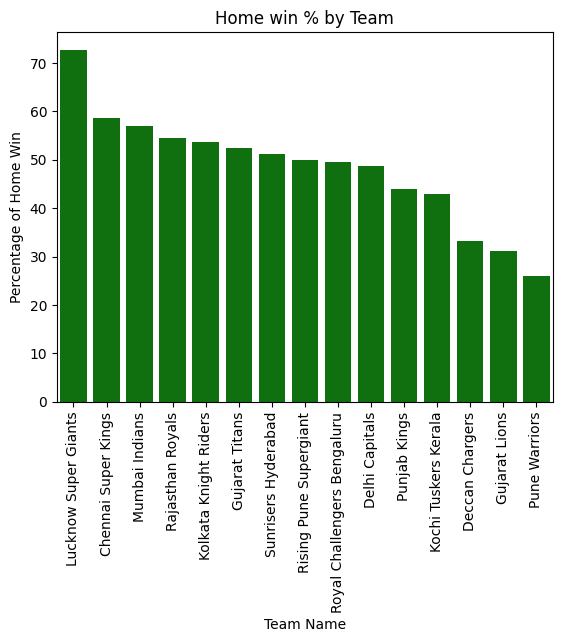

In [46]:
new_df=matches[matches['winner'].notnull()]
teams=new_df['team1'].unique()
l1=[]
for team in teams:
    home_play=new_df[new_df['team1']==team].shape[0]
    home_win=new_df[(new_df['team1']==team)&(new_df['winner']==team)].shape[0]
    home_win_percent=(home_win/home_play)*100
    l1.append({
    'Team_Name':team,
    'Win_Percent':home_win_percent})
result=round(pd.DataFrame(l1).sort_values('Win_Percent',ascending=False),2)
print(f'Highest home win at city is:\n{result}')

#Visualization all team who have highest win percent in home city
sns.barplot(data=result,x='Team_Name',y='Win_Percent',color='green')
plt.title("Home win % by Team")
plt.xlabel("Team Name")
plt.ylabel("Percentage of Home Win")
plt.xticks(rotation='vertical')

#### Lucknow Super Giants lead all teams with a home win rate of XX%, showing a clear dominance at their home ground. In contrast, Pune Warriors have the lowest home win rate at YY%, highlighting their struggles in home matches.


#### How many matches were won by run and won by wicket?

Match won by run and won by wicket is:
result
wickets    578
runs       498
Name: count, dtype: int64


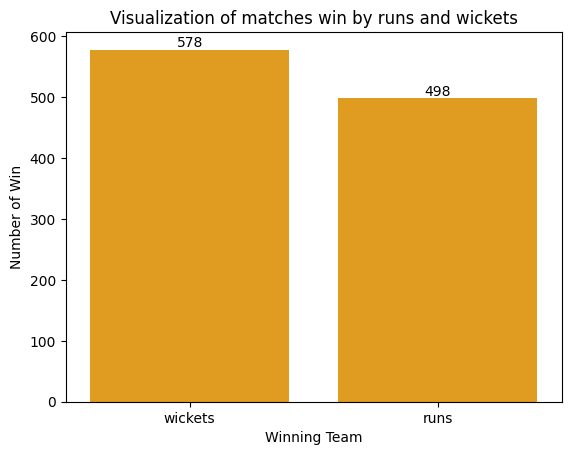

In [48]:
result=matches['result'].value_counts().head(2)
print(f'Match won by run and won by wicket is:\n{result}')

#visualization of matches won by run and by wicket
x=result.index
y=result.values
sns.barplot(x=x,y=y,color='orange')
for i,value in enumerate(y):
    plt.text(i,value+5,value,ha='center')
plt.title("Visualization of matches win by runs and wickets")
plt.xlabel("Winning Team")
plt.ylabel("Number of Win")
plt.show()

#### From the visualization we can clearly conclude the number of matches win by wicket is more than the number of matches win by runs

#### what is the highest win by run in ipl history?

Highest win by run in ipl history is:146.0


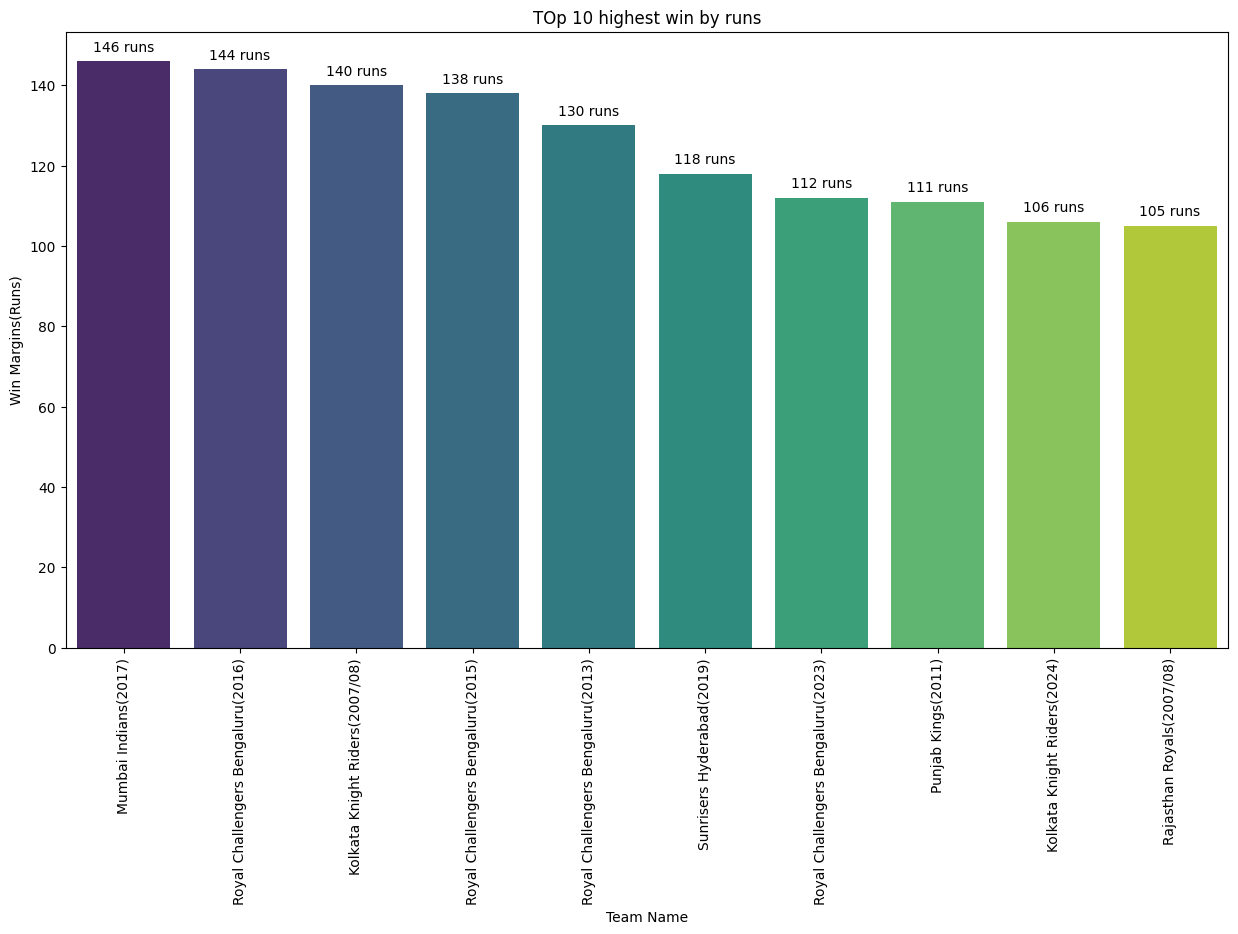

In [67]:
new_df=matches[matches['result']=='runs']
result=new_df['result_margin'].max()
print(f'Highest win by run in ipl history is:{result}')

#Visualization of top 10 highest win by runs
fig,ax=plt.subplots(figsize=(15,8))
top10=new_df.nlargest(10,'result_margin')
label=top10['winner']+'('+top10['season']+')'
sns.barplot(data=top10,x=label,y='result_margin',hue=label,legend=False,palette='viridis')
for container in ax.containers:
    ax.bar_label(container,fmt='%d runs',padding=5)
plt.title("TOp 10 highest win by runs")
plt.xlabel('Team Name')
plt.ylabel("Win Margins(Runs)")
plt.xticks(rotation='vertical')
plt.show()
          

#### Mumbai Indians hold the record for the largest win by runs in IPL history, defeating Delhi Daredevils by 146 runs in 2017. Royal Challengers Bangalore follow closely with a 144‑run victory over Gujarat Lions in 2016, marking the second‑largest margin.


#### What is the highest win by wicket in ipl history ?

Highest win by wicket in ipl history is:10.0


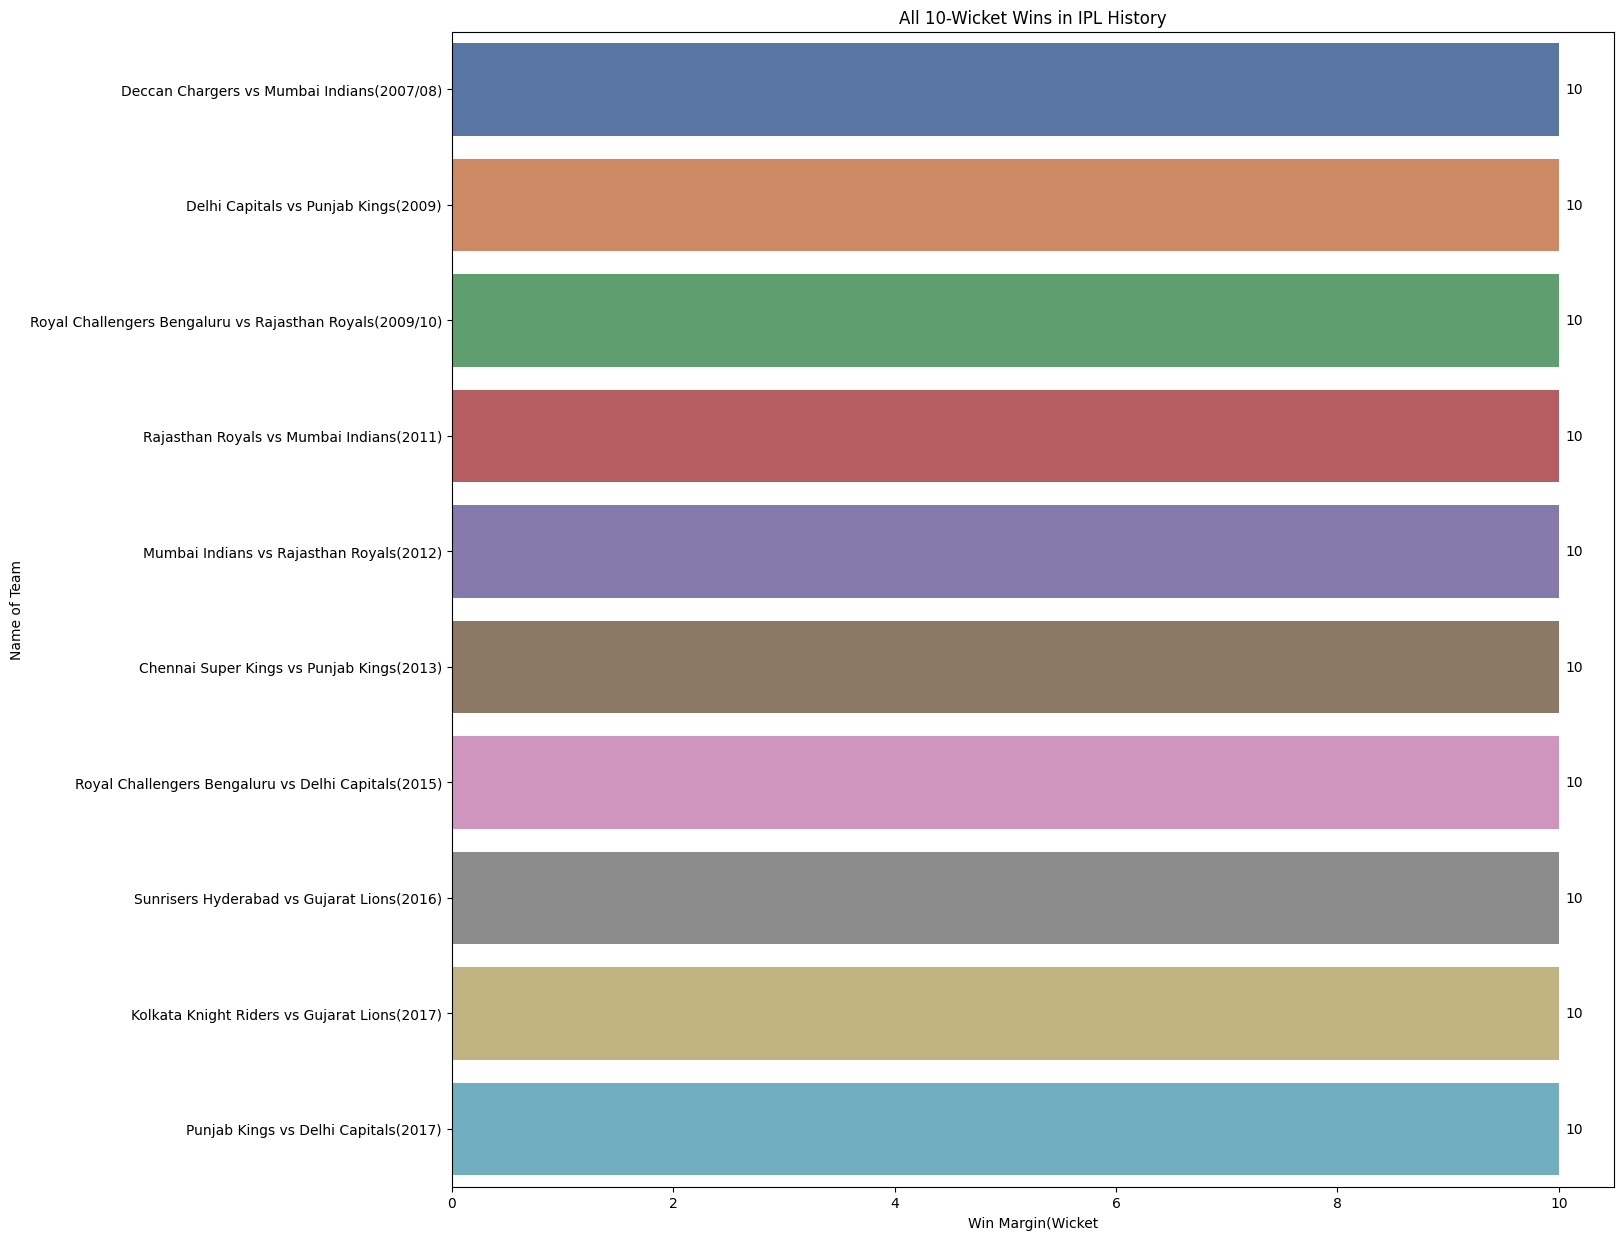

In [90]:
new_df=matches[matches['result']=='wickets']
result=new_df['result_margin'].max()
print(f'Highest win by wicket in ipl history is:{result}')

#Visualization of top 10 highest win by wickets
temp=new_df.copy()
temp['loser']=temp.apply(lambda row:row['team1'] if row['winner']==row['team2'] else row['team2'],axis=1)
top10=temp.nlargest(10,'result_margin')
label=top10['winner']+' vs ' +top10['loser']+'('+top10['season']+')'
fig,ax=plt.subplots(figsize=(15,15))
sns.barplot(data=top10,x='result_margin',y=label,hue=label,legend=False,palette='deep')
for container in ax.containers:
    plt.bar_label(container,fmt="%d",padding=5)
plt.title("All 10-Wicket Wins in IPL History")
plt.xlabel("Win Margin(Wicket")
plt.ylabel("Name of Team")
plt.show()

#### In IPL history, the highest possible win margin by wickets is 10. Several teams have achieved this rare feat across different seasons, showcasing complete dominance in their chase. Highlighting these matches (Winner vs Loser, Season) provides richer storytelling than just plotting the margin itself.

####  which team had won by highes runs against which team?

In [22]:
new_df=matches[matches['result']=='runs']
result=new_df[new_df['result_margin']==146]
result[['team1','team2','winner','result','result_margin']]

,team1,team2,winner,result,result_margin
620,Delhi Capitals,Mumbai Indians,Mumbai Indians,runs,146.0


#### How many super over matches were happen?

In [23]:
result=(matches['super_over']=='Y').sum()
print(f'Total super matches were:{result}')

Total super matches were:14


#### Which player has won most player of the match?

In [24]:
result=matches['player_of_match'].value_counts().index[0]
print(f'The player who have won most man of the match:{result}')

The player who have won most man of the match:AB de Villiers


#### Which player have won most man of the match in a single sesason?

In [25]:
result=matches.groupby('season',as_index=False)['player_of_match'].value_counts().sort_values('count',ascending=False)['player_of_match'].head(1)
print(f'Player who have won most player of match in a single season:\n{result}')

Player who have won most player of match in a single season:
126    CH Gayle
Name: player_of_match, dtype: object


##### Which venue hosted the most matches?

In [26]:
venue=matches['venue'].value_counts().idxmax()
count=matches['venue'].value_counts().max()
print(f"{venue} have hosted the most matches and number of times is {count}")

Eden Gardens have hosted the most matches and number of times is 77


#### Which team  performs best at which venue?

In [27]:
result=matches.groupby(['venue','winner']).size().reset_index(name='count').sort_values('count',ascending=False)
result.head(1)

,venue,winner,count
82,Eden Gardens,Kolkata Knight Riders,45


#### Which City has hosted must match?

In [28]:
top_city=matches['city'].value_counts().idxmax()
count=matches['city'].value_counts().max()
print(f'{top_city} has hosted must matches: {count} matches')

Mumbai has hosted must matches: 173 matches


#### How many total balls were bowled across all  season?

In [29]:
total_ball=ball['ball'].count()
print(f'Total ball across all season:{total_ball}')

Total ball across all season:260920


In [30]:
matches.shape

(1095, 20)

#### How many total runs were scored across all season?

In [31]:
total_runs=ball['total_runs'].sum()
print(f'Total runs scored across all season:{total_runs}')

Total runs scored across all season:347756


#### What is the average run per over  across all season?

In [32]:
total_overs=ball.groupby(['match_id','inning'])['over'].nunique().sum()
total_runs=ball['total_runs'].sum()
average_runs_per_over=total_runs/total_overs
print(f"Average run per over across all season:{round(average_runs_per_over,2)}")

Average run per over across all season:8.24


#### How scored must run acoss all season?

In [33]:
batsman_name=ball.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).idxmax()
total_runs=ball.groupby('batter')['batsman_runs'].sum().sort_values().max()
print(f"{batsman_name} has scored most run across in all ipl season and scored runs:{total_runs}")

V Kohli has scored most run across in all ipl season and scored runs:8014


#### Which batsman had most boundaries 4s?

In [34]:
new_df=ball[ball['batsman_runs']==4]
batsman_name=new_df.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).idxmax()
total_fours=new_df.groupby('batter')['batsman_runs'].count().max()
print(f"{batsman_name} had hit all the more 4's and total number of 4's:{total_fours}")

S Dhawan had hit all the more 4's and total number of 4's:768


#### Which batsman had hit most 6s?

In [35]:
new_df=ball[ball['batsman_runs']==6]
batsman_name=new_df.groupby('batter')['batsman_runs'].count().idxmax()
total_fours=new_df.groupby('batter')['batsman_runs'].count().max()
print(f"{batsman_name} had hit all the more 6's and total number of 6's:{total_fours}")

CH Gayle had hit all the more 6's and total number of 6's:359


#### Which Batsman had best strike rate over all ipl season?

In [36]:
new_df=ball[ball['extras_type']!='wides']
total_runs=new_df.groupby('batter')['batsman_runs'].sum()
total_balls=new_df.groupby('batter')['ball'].count()
#player who had faced more than 100 ball 
a=total_balls[total_balls>=100]
#player who had hit run who faced more than 100 balls
b=total_runs[total_balls>=100]
strike_rate=(b/a)*100
batsman_name=strike_rate.idxmax()
strike=strike_rate.max()
print(f"{batsman_name} had best strike rate across all ipl  season and strike rate (minimum 100 ball faced):{strike:.2f}")

J Fraser-McGurk had best strike rate across all ipl  season and strike rate (minimum 100 ball faced):234.04


#### Which team scored must run overall?

In [37]:
team_name=ball.groupby('batting_team')['total_runs'].sum().idxmax()
total_runs=ball.groupby('batting_team')['total_runs'].sum().max()
print(f"{team_name} had scored must run overall and total runs:{total_runs}")

Mumbai Indians had scored must run overall and total runs:42176


#### How had taken must wicket in ipl ?

In [38]:
baller_name=ball.groupby('bowler')['is_wicket'].sum().idxmax()
total_wicket=ball.groupby('bowler')['is_wicket'].sum().max()
print(f"{baller_name} had taken must wicket and total number of wicket:{total_wicket}")

YS Chahal had taken must wicket and total number of wicket:213


In [39]:
ball['batsman_runs']

0         0
1         0
2         0
3         0
4         0
         ..
260915    1
260916    1
260917    1
260918    1
260919    1
Name: batsman_runs, Length: 260920, dtype: int64

#### Which baller had best economy rate?

In [40]:
new_df=ball[ball['extras_type']!='wides']
baller_get_run=new_df.groupby('bowler')['total_runs'].sum()
total_ball=new_df.groupby('bowler')['ball'].count()
#filtering baller who ball at least 24 ball
mask=total_ball>=24
total_over=total_ball[mask]/6
total_run=baller_get_run[mask]
economy=round(total_run/total_over,2)
baller_name=economy.idxmin()
economic_rate=economy.min()
print(f"{baller_name} had best strike rate and had economic_rate {economic_rate}")

NB Singh had best strike rate and had economic_rate 4.25


In [41]:
ball['ball'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

#### Which baller bowled most wides?

In [42]:
new_df=ball[ball['extras_type']=='wides']
baller_name=new_df.groupby('bowler')['ball'].count().idxmax()
total_ball=new_df.groupby('bowler')['ball'].count().max()
print(f"{baller_name} had most wides ball and total number of balls {total_ball}")

DJ Bravo had most wides ball and total number of balls 167


#### What is the most common type of dismissal type?

In [43]:
types=ball['dismissal_kind'].value_counts().idxmax()
times=ball['dismissal_kind'].value_counts().max()
print(f"{types} is most common type of dismissal and total number of times {times}")

caught is most common type of dismissal and total number of times 8063


#### Which fielder took must catches?

In [44]:
new_df=ball[ball['dismissal_kind']=='caught']
fielder_name=new_df.groupby('fielder')['dismissal_kind'].count().idxmax()
times=new_df.groupby('fielder')['dismissal_kind'].count().max()
print(f"{fielder_name} had taken must number of times catch and taken {times} times")   

MS Dhoni had taken must number of times catch and taken 152 times


#### Which batsman got much times out by catch?

In [45]:
new_df=ball[ball['dismissal_kind']=='caught']
batter=new_df.groupby('batter')['dismissal_kind'].count().idxmax()
times=new_df.groupby('batter')['dismissal_kind'].count().max()
print(f"{batter} had got much times out by catch and number of times is {times}")

RG Sharma had got much times out by catch and number of times is 157


#### Find the last match played by V kholi in Delhi?

In [46]:
temp=ball.merge(matches,left_on='match_id',right_on='id')
new_df=temp[(temp['batter']=='V Kohli')&(temp['city']=="Delhi")]
last_match=new_df.sort_values('date',ascending=False).head(1)[['id','city','team1','team2','date']]
last_match

,id,city,team1,team2,date
237892,1359524,Delhi,Royal Challengers Bengaluru,Delhi Capitals,2023-05-06


#### Find best bowler in death overs?
* Note: Have taken most no of wickets in case of tie with least economy

In [47]:
temp=ball[(ball['over']>15)&(ball['extras_type']!='wides')]
new_df=temp[temp['dismissal_kind']!='run out']
df=new_df.groupby('bowler').agg({
    'ball':'count',
    'total_runs':'sum',
    'is_wicket':'sum'}).sort_values('is_wicket',ascending=False)
overs=df['ball']/6
df['economy']=df['total_runs']/overs
result=df.sort_values(['is_wicket','economy'],ascending=[False,True]).index[0]
print(f"The best bowler in dead over is {result}")

The best bowler in dead over is DJ Bravo


#### Find the orange cap older of 2024?

In [48]:
# Merge season info
temp = ball.merge(matches[['id','season']], left_on='match_id', right_on='id')

# Filter 2024 season
season_2024 = temp[temp['season'] == '2024']

# Exclude wides for strike rate calculation
legal_balls = season_2024[season_2024['extras_type'] != 'wides']

# Total runs per batsman
total_runs = season_2024.groupby('batter')['batsman_runs'].sum()

# Balls faced per batsman (legal balls only)
balls_faced = legal_balls.groupby('batter')['ball'].count()

# Strike rate per batsman
strike_rate = (total_runs / balls_faced) * 100

# Combine runs and strike rate
stats = pd.DataFrame({
    'runs': total_runs,
    'strike_rate': strike_rate
})
# Sort: first by runs DESC, then strike rate DESC
stats_sorted = stats.sort_values(['runs','strike_rate'], ascending=[False, False])
# Orange Cap holder
orange_cap_batsman = stats_sorted.index[0]
orange_cap_runs = stats_sorted.iloc[0]['runs']
orange_cap_sr = stats_sorted.iloc[0]['strike_rate']
print(f"Orange Cap IPL 2024: {orange_cap_batsman}")
print(f"Runs: {orange_cap_runs}, Strike Rate: {orange_cap_sr:.2f}")


Orange Cap IPL 2024: V Kohli
Runs: 741.0, Strike Rate: 154.70


#### Find the orange cap holder of each season in case of same run batter with highest strike rate will win?

In [111]:
#mergeing matches table to obtain information
temp=ball.merge(matches[['id','season']],how='inner',left_on='match_id',right_on='id')

#Excluding the wides for strike rate calculation
legal_cricket=temp[temp['extras_type']!='wides']

#calculating runs per batsman in each season
batsman_per_season=legal_cricket.groupby(['season','batter'],as_index=False)['batsman_runs'].sum()

#Ball faced per player per season
ball_per_season=legal_cricket.groupby(['season','batter'],as_index=False)['ball'].count()
stats=batsman_per_season.merge(ball_per_season,on=['season','batter'])

#Calculating strike rate for each batsman
stats['strike']=(stats['batsman_runs']/stats['ball'])*100

#Sort per season
result=stats.sort_values(['season','batsman_runs','strike'],ascending=[True,False,False])

#Picking top batsman per season
orange_cap_holder=result.drop_duplicates(subset='season',keep='first')
print(orange_cap_holder)

       season         batter  batsman_runs  ball      strike
115   2007/08       SE Marsh           616   441  139.682540
229      2009      ML Hayden           572   395  144.810127
446   2009/10   SR Tendulkar           618   466  132.618026
502      2011       CH Gayle           608   332  183.132530
684      2012       CH Gayle           733   456  160.745614
910      2013     MEK Hussey           733   566  129.505300
1088     2014     RV Uthappa           660   479  137.787056
1148     2015      DA Warner           562   359  156.545961
1383     2016        V Kohli           973   640  152.031250
1422     2017      DA Warner           641   452  141.814159
1594     2018  KS Williamson           735   516  142.441860
1694     2019      DA Warner           692   481  143.866944
1866  2020/21       KL Rahul           676   524  129.007634
2051     2021     RD Gaikwad           635   466  136.266094
2144     2022     JC Buttler           863   579  149.050086
2423     2023   Shubman 

#### Find the purple cap holder of each season in case of tie player with less economy rate will win?

In [110]:
#merge ball dataframe with matches dataframe to get season info
temp=ball.merge(matches[['id','season']],left_on='match_id',right_on='id')

#calculate wicket per bowler in each season
valid_dismissal=['bowled','caught','lbw','stumped','hit wicket']
temp['is_wicket']=temp['dismissal_kind'].isin(valid_dismissal)
wickets=temp.groupby(['season','bowler'])['is_wicket'].sum().reset_index(name='wickets')

#calculating run conceded by bowler in each season
# Runs conceded = total runs off bat + extras (wides, no-balls, byes, leg-byes)
runs=temp.groupby(['season','bowler'])['total_runs'].sum().reset_index(name='run conceded')

#calculating the over bowled:only counnting legal balls
legal_deliveries=temp[~temp['extras_type'].isin(['wides','noballs'])]
balls=legal_deliveries.groupby(['season','bowler'])['ball'].count().reset_index(name='balls_bowled')
balls['overs']=balls['balls_bowled']/6
balls

#combine stats
final_df=wickets.merge(runs,on=['season','bowler']).merge(balls,on=['season','bowler'])
final_df['economy_rate']=final_df['run conceded']/final_df['overs']
result=(final_df.sort_values(['wickets','economy_rate'],ascending=[False,True])
        .drop_duplicates(subset='season',keep='first').sort_values('season'))

print(result[['season','bowler','wickets','economy_rate']])

       season          bowler  wickets  economy_rate
84    2007/08   Sohail Tanvir       22      6.680162
174      2009        RP Singh       22      7.206704
284   2009/10         PP Ojha       21      7.461756
447      2011      SL Malinga       26      6.238095
537      2012        M Morkel       25      7.396825
629      2013        DJ Bravo       30      8.080000
779      2014       MM Sharma       23      8.489164
847      2015        DJ Bravo       25      8.445860
938      2016         B Kumar       22      7.621212
1048     2017         B Kumar       25      7.337580
1144     2018          AJ Tye       24      8.196429
1278     2019        K Rabada       25      7.958333
1381  2020/21        K Rabada       32      8.517588
1467     2021        HV Patel       32      8.183432
1671     2022       YS Chahal       27      7.882353
1755     2023  Mohammed Shami       27      8.163683
1841     2024        HV Patel       24      9.897959
